In [2]:
pip install scikit-learn

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

### Creacion de la conexion a la base de datos para leer la tabla "Player Atrributes

In [2]:
cnx = sqlite3.connect('database.sqlite')

In [3]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)

In [4]:
df.head(10)

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
5,6,189615,155782,2016-04-21 00:00:00,74.0,76.0,left,high,medium,80.0,...,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
6,7,189615,155782,2016-04-07 00:00:00,74.0,76.0,left,high,medium,80.0,...,66.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
7,8,189615,155782,2016-01-07 00:00:00,73.0,75.0,left,high,medium,79.0,...,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
8,9,189615,155782,2015-12-24 00:00:00,73.0,75.0,left,high,medium,79.0,...,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0
9,10,189615,155782,2015-12-17 00:00:00,73.0,75.0,left,high,medium,79.0,...,65.0,59.0,76.0,75.0,78.0,14.0,7.0,9.0,9.0,12.0


In [8]:
df.shape

(183978, 42)

In [9]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='str')

### de todas las columnas, determinamos cuales se usaran con "Features" para alimentar el modelo

In [ ]:
features1 = ['potential','crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes']
#0.8412591456264535 mejor 
#0.8412690897596594


In [43]:
features1 = ['potential', 
             'crossing', 
             'finishing', 
             'heading_accuracy', 
             'short_passing', 
             'volleys', 
             'dribbling', 
             'curve', 
             'free_kick_accuracy', 
             'long_passing', 
             'ball_control', 
             'acceleration', 
             'sprint_speed', 
             'agility', 
             'reactions', 
             'balance', 
             'shot_power', 
             'jumping', 
             'stamina', 
             'strength', 
             'long_shots', 
             'aggression', 
             'interceptions', 
             'positioning', 
             'penalties', 
             'marking', 
             'sliding_tackle', 
             'gk_diving', 
             'gk_handling', 
             'gk_kicking', 
             'gk_positioning', 
             'gk_reflexes']
target = ['overall_rating']
#para ejecucion mas eficaz
df = df.dropna()
x = df[features1]
y = df[target]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=324)
scale = preprocessing.StandardScaler()
scale.fit(x_train)
x_train = scale.transform(x_train)
regresor = LinearRegression()
regresor.fit(x_train, y_train)
x_test = scale.transform(x_test)
y_prediccion = regresor.predict(x_test)
y_result = y_prediccion - y_test
RMSE = sqrt(mean_squared_error(y_true=y_test, y_pred=y_prediccion))
regresor.score(x_test,y_test) 


0.8412591456264535

In [7]:
#limpando filas con datos nan
df = df.dropna()


In [8]:
#separamos caracteristicas en x, y el target en Y
x = df[features1]
y = df[target]

In [9]:
x.iloc[3]

potential             65.0
crossing              48.0
finishing             43.0
heading_accuracy      70.0
short_passing         60.0
volleys               43.0
dribbling             50.0
curve                 44.0
free_kick_accuracy    38.0
long_passing          63.0
ball_control          48.0
acceleration          60.0
sprint_speed          64.0
agility               59.0
reactions             46.0
balance               65.0
shot_power            54.0
jumping               58.0
stamina               54.0
strength              76.0
long_shots            34.0
aggression            62.0
interceptions         40.0
positioning           44.0
vision                53.0
penalties             47.0
marking               62.0
standing_tackle       63.0
sliding_tackle        66.0
Name: 3, dtype: float64

In [10]:
y.head()

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


In [11]:
# Muestreo de los valores de la feature "reactions" para cada jugador
x['reactions']

0         47.0
1         47.0
2         47.0
3         46.0
4         46.0
          ... 
183973    86.0
183974    74.0
183975    74.0
183976    69.0
183977    66.0
Name: reactions, Length: 180354, dtype: float64

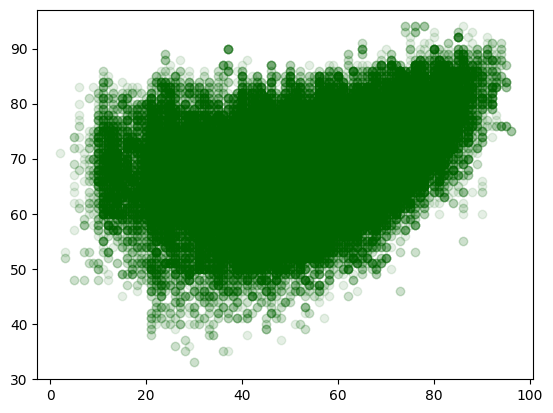

In [12]:
#imprimir la relacion existente entre el feature "reactions" y el target "overall rating"
plt.scatter(x['penalties'], y, color="darkgreen", label="Datos", alpha=.1)

In [13]:
#separacion de los datos en training y test datasets
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=324)

In [14]:
#se hace escalado estandar para que los datos de cada feature se acople a un rango y se eviten sesgos de un feature con valores muy altos que puedan influir de mas en el target
scale = preprocessing.StandardScaler()


In [15]:
#entrenar con los datos escalados
scale.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
x_train = scale.transform(x_train)

In [17]:
#imprimir los nuevos valores minimo y maximo de las features de entrenamiento
x_train.min()

np.float64(-5.377337896778157)

In [18]:
x_train.max()

np.float64(3.571741815924366)

In [19]:
# Creamos instancia del modelo de regresion lineal de scikit learn
regresor = LinearRegression()

In [ ]:
# ajustando el modelo a los datos de entrenamiento
regresor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
# Realizar prediccion usando el conjunto de datos de prueba (test set)
    #escalar valores de prueba para que coincidan con los de entrenamiento
x_test = scale.transform(x_test)

In [22]:
#hacer prediccion del valor de salida, pasandole los valores de prueba
y_prediccion = regresor.predict(x_test)

In [23]:
#obtener la diferencia que hay entre los valores de salida predichos contra los valores reales
y_result = y_prediccion - y_test
y_result

,overall_rating
35543,1.166546
28735,-3.325493
168029,1.129905
138117,-0.754775
123316,-0.111898
...,...
51151,-0.176664
155333,-3.126078
118067,-2.085589
62126,0.200511


In [24]:
#se calcula raiz cuadrada del error cuadratico medio
RMSE = sqrt(mean_squared_error(y_true=y_test, y_pred=y_prediccion))
print(RMSE)

3.2357972494784546


In [25]:
# mostrar la presicion que obtuvo el modelo al predecir con valores de prueba
regresor.score(x_test,y_test) 

0.788814282780975

In [26]:
# mostrar cual es el valor de cada w que se aplico a cada feature (w * x) para que al sumar todos los productos nos de el puntaje de cada jugador
regresor.coef_

array([[ 3.34365293,  0.65056747,  0.00892135, -0.28909437,  0.03087494,
         0.01371926, -0.33080107,  0.06748248,  0.09214954,  0.65756625,
         0.29606339, -0.24432222, -0.28270356, -0.02660177,  2.81502245,
        -0.04667023,  0.27883551,  0.49111156, -0.17728766,  1.07958904,
        -0.08334484,  0.19654988, -0.03984698, -0.27733103, -0.0580898 ,
         0.21056145,  0.44691139, -0.02165471, -1.00314107]])